# KKBox Churn — XGBoost Hyperparameter Tuning

Tunes **XGBoost only** on the same train/test split and the same two feature sets
(full vs. proxy-controlled) as `03_tree_models.ipynb`, so results are directly comparable to the
untuned XGBoost baseline.

## Resource-conscious search design (host has ~7.4GB RAM total)

- **A single stratified train/validation split is used for candidate scoring, not k-fold CV.**
  With 776,768 training rows, a single validation split already gives a stable ROC-AUC estimate,
  and it avoids multiplying every candidate fit by *k* folds.
- **Preprocessing is fit once per feature set, not once per candidate.** The `ColumnTransformer`
  (one-hot + median-impute/scale) doesn't depend on any XGBoost hyperparameter, so encoding
  `X_train` once and running the search directly on the encoded matrix avoids ~16x redundant
  preprocessing work per feature set.
- **A small `RandomizedSearchCV` (`n_iter=15`), not a grid search.** The 6-parameter space below
  has thousands of combinations; random sampling covers it far more cheaply than an exhaustive grid.
- **The search itself runs sequentially (`n_jobs=1`)** so only one model is ever being trained at
  a time; each individual XGBoost fit still uses `n_jobs=4` internally (thread-based, so it doesn't
  duplicate the dataset across worker processes the way multi-process search parallelism would).
- **`scale_pos_weight` stays fixed** at the same train-set neg/pos ratio used in
  `03_tree_models.ipynb` — it isn't one of the six parameters requested for tuning.
- **ROC-AUC is the sole selection metric**, per the brief. No SMOTE is used anywhere.

After search, the best parameters are refit into a full `Pipeline` (preprocessing + XGBoost) on
all of `X_train`, and evaluated on the same held-out `X_test` used throughout this project — this
is the number compared against the untuned XGBoost baseline. The source dataset is not modified.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, log_loss, confusion_matrix,
)
from xgboost import XGBClassifier
import joblib

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Load data + feature sets + train/test split (identical to `03_tree_models.ipynb`)

In [2]:
DATA_PATH = Path("..") / "outputs" / "kkbox_modeling_dataset_v2.csv"

usecols = [c for c in pd.read_csv(DATA_PATH, nrows=0).columns if c != "msno"]
df = pd.read_csv(DATA_PATH, usecols=usecols)

CAT_ONEHOT = ["city", "gender", "registered_via", "latest_payment_method_id",
              "registration_month", "num_distinct_payment_methods"]

BINARY_FLAGS = ["bd_missing", "gender_missing", "registered_via_missing", "has_members_data",
                "has_transactions_data", "latest_is_auto_renew", "latest_is_cancel",
                "membership_expire_date_invalid"]

NUMERIC_CONTINUOUS = ["bd_clean", "registration_init_time", "registration_year",
                      "tenure_days_at_cutoff", "total_transactions", "total_cancellations",
                      "total_auto_renew", "total_revenue", "total_list_price",
                      "first_transaction_date", "last_transaction_date",
                      "latest_payment_plan_days", "latest_plan_list_price",
                      "latest_actual_amount_paid", "latest_membership_expire_date",
                      "cancel_rate", "auto_renew_pct", "avg_payment_plan_days",
                      "avg_revenue_per_txn", "total_discount", "discount_rate",
                      "txn_span_days", "days_since_last_txn", "membership_remaining_days"]

ALL_FEATURES = CAT_ONEHOT + BINARY_FLAGS + NUMERIC_CONTINUOUS
assert len(ALL_FEATURES) == df.shape[1] - 1

df[CAT_ONEHOT] = df[CAT_ONEHOT].astype(str)

PROXY_EXCLUDE = [
    "membership_remaining_days", "days_since_last_txn", "latest_is_cancel",
    "last_transaction_date", "latest_membership_expire_date", "membership_expire_date_invalid",
]

X = df[ALL_FEATURES]
y = df["is_churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight (fixed, not tuned) = {scale_pos_weight:.3f}")

# Single stratified validation split for candidate scoring during the search (positions into X_train).
idx_all = np.arange(len(X_train))
idx_tr, idx_val = train_test_split(idx_all, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)
print(f"Search train fold: {len(idx_tr):,} rows  |  Search validation fold: {len(idx_val):,} rows")


Train: 776,768 rows  |  Test: 194,192 rows
scale_pos_weight (fixed, not tuned) = 10.118


Search train fold: 621,414 rows  |  Search validation fold: 155,354 rows


## 2. Preprocessing (fit once per feature set) + evaluation helper

In [3]:
def build_preprocessor(exclude_cols):
    cat_cols = [c for c in CAT_ONEHOT if c not in exclude_cols]
    num_cols = [c for c in (BINARY_FLAGS + NUMERIC_CONTINUOUS) if c not in exclude_cols]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols),
    ])


def evaluate_model(pipeline, X_test, y_test, name):
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    metrics = {
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
        "pr_auc": float(average_precision_score(y_test, y_proba)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "log_loss": float(log_loss(y_test, y_proba)),
    }
    cm = confusion_matrix(y_test, y_pred)

    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    print("  confusion matrix [[TN, FP], [FN, TP]]:")
    print(" ", cm.tolist())

    return metrics, y_proba, y_pred, cm


## 3. Search space

Sensible, commonly-used ranges for each of the six requested parameters.

In [4]:
PARAM_DIST = {
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}
N_ITER = 15
print(f"Search space size: {5*5*3*4*3*3:,} combinations; sampling {N_ITER} per feature set "
      f"(x2 feature sets = {2*N_ITER} candidate fits total, plus 2 final refits).")


def tune_xgboost(exclude_cols, feature_set_name):
    preprocessor = build_preprocessor(exclude_cols)
    X_train_enc = preprocessor.fit_transform(X_train)

    base_clf = XGBClassifier(
        tree_method="hist", scale_pos_weight=scale_pos_weight,
        n_jobs=4, random_state=RANDOM_STATE, eval_metric="logloss",
    )
    search = RandomizedSearchCV(
        base_clf, PARAM_DIST, n_iter=N_ITER, scoring="roc_auc",
        cv=[(idx_tr, idx_val)], random_state=RANDOM_STATE, n_jobs=1, verbose=1, refit=True,
    )
    search.fit(X_train_enc, y_train)

    print(f"\n--- {feature_set_name}: best params (by validation ROC-AUC={search.best_score_:.4f}) ---")
    print(search.best_params_)

    # Refit the winning config as a full, self-contained Pipeline (raw-input-friendly,
    # consistent with how every other model in this project is saved).
    tuned_pipeline = Pipeline([
        ("preprocess", build_preprocessor(exclude_cols)),
        ("clf", XGBClassifier(
            **search.best_params_, tree_method="hist", scale_pos_weight=scale_pos_weight,
            n_jobs=4, random_state=RANDOM_STATE, eval_metric="logloss",
        )),
    ])
    tuned_pipeline.fit(X_train, y_train)
    return tuned_pipeline, search.best_params_, float(search.best_score_)


Search space size: 2,700 combinations; sampling 15 per feature set (x2 feature sets = 30 candidate fits total, plus 2 final refits).


## 4. Tune on the full feature set

In [5]:
tuned_xgb_full, best_params_full, best_val_auc_full = tune_xgboost(exclude_cols=[], feature_set_name="Full feature set")
metrics_tuned_full, proba_tuned_full, pred_tuned_full, cm_tuned_full = evaluate_model(
    tuned_xgb_full, X_test, y_test, "XGBoost (tuned) - full feature set"
)


Fitting 1 folds for each of 15 candidates, totalling 15 fits



--- Full feature set: best params (by validation ROC-AUC=0.9171) ---
{'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


=== XGBoost (tuned) - full feature set ===
  roc_auc   : 0.9167
  pr_auc    : 0.7114
  precision : 0.4301
  recall    : 0.8092
  f1        : 0.5617
  log_loss  : 0.3278
  confusion matrix [[TN, FP], [FN, TP]]:
  [[157996, 18730], [3332, 14134]]


## 5. Tune on the proxy-controlled feature set

In [6]:
tuned_xgb_proxy, best_params_proxy, best_val_auc_proxy = tune_xgboost(exclude_cols=PROXY_EXCLUDE, feature_set_name="Proxy-controlled feature set")
metrics_tuned_proxy, proba_tuned_proxy, pred_tuned_proxy, cm_tuned_proxy = evaluate_model(
    tuned_xgb_proxy, X_test, y_test, "XGBoost (tuned) - proxy-controlled feature set"
)


Fitting 1 folds for each of 15 candidates, totalling 15 fits



--- Proxy-controlled feature set: best params (by validation ROC-AUC=0.9027) ---
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.6}


=== XGBoost (tuned) - proxy-controlled feature set ===
  roc_auc   : 0.9030
  pr_auc    : 0.6598
  precision : 0.3838
  recall    : 0.7925
  f1        : 0.5172
  log_loss  : 0.3584
  confusion matrix [[TN, FP], [FN, TP]]:
  [[154507, 22219], [3625, 13841]]


## 6. Tuned vs. untuned XGBoost, and the full model comparison

In [7]:
with open(Path("..") / "models" / "tree_model_metrics.json") as f:
    tree_metrics = json.load(f)
with open(Path("..") / "models" / "baseline_metrics.json") as f:
    logreg_metrics = json.load(f)

all_metrics = {
    "LogReg - full": logreg_metrics["full_feature_set"],
    "LogReg - proxy-controlled": logreg_metrics["proxy_controlled_set"],
    "RandomForest - full": tree_metrics["random_forest_full"],
    "RandomForest - proxy-controlled": tree_metrics["random_forest_proxy_controlled"],
    "XGBoost (untuned) - full": tree_metrics["xgboost_full"],
    "XGBoost (untuned) - proxy-controlled": tree_metrics["xgboost_proxy_controlled"],
    "XGBoost (tuned) - full": metrics_tuned_full,
    "XGBoost (tuned) - proxy-controlled": metrics_tuned_proxy,
}
comparison = pd.DataFrame(all_metrics).T[["roc_auc", "pr_auc", "precision", "recall", "f1", "log_loss"]]
comparison.sort_values("roc_auc", ascending=False)


,roc_auc,pr_auc,precision,recall,f1,log_loss
XGBoost (tuned) - full,0.916679,0.711363,0.430075,0.809229,0.561653,0.327828
XGBoost (untuned) - full,0.916525,0.709627,0.423872,0.812264,0.557052,0.329983
RandomForest - full,0.913182,0.687722,0.429594,0.803847,0.559943,0.340183
XGBoost (tuned) - proxy-controlled,0.902952,0.659801,0.383833,0.792454,0.517169,0.358424
XGBoost (untuned) - proxy-controlled,0.901814,0.651751,0.380796,0.789935,0.513874,0.367412
RandomForest - proxy-controlled,0.893488,0.606546,0.379351,0.763827,0.506935,0.391432
LogReg - full,0.887693,0.624597,0.433990,0.760563,0.552637,0.387762
LogReg - proxy-controlled,0.828919,0.485513,0.322310,0.645597,0.429963,0.483467


In [8]:
xgb_only = comparison.loc[[
    "XGBoost (untuned) - full", "XGBoost (tuned) - full",
    "XGBoost (untuned) - proxy-controlled", "XGBoost (tuned) - proxy-controlled",
]]
print("XGBoost tuned vs. untuned:")
print(xgb_only[["roc_auc", "pr_auc"]].to_string())
print()

gain_full = metrics_tuned_full["roc_auc"] - tree_metrics["xgboost_full"]["roc_auc"]
gain_proxy = metrics_tuned_proxy["roc_auc"] - tree_metrics["xgboost_proxy_controlled"]["roc_auc"]
pr_gain_full = metrics_tuned_full["pr_auc"] - tree_metrics["xgboost_full"]["pr_auc"]
pr_gain_proxy = metrics_tuned_proxy["pr_auc"] - tree_metrics["xgboost_proxy_controlled"]["pr_auc"]

print(f"Full feature set:            ROC-AUC {tree_metrics['xgboost_full']['roc_auc']:.4f} -> {metrics_tuned_full['roc_auc']:.4f}  (delta {gain_full:+.4f})")
print(f"                              PR-AUC  {tree_metrics['xgboost_full']['pr_auc']:.4f} -> {metrics_tuned_full['pr_auc']:.4f}  (delta {pr_gain_full:+.4f})")
print(f"Proxy-controlled feature set: ROC-AUC {tree_metrics['xgboost_proxy_controlled']['roc_auc']:.4f} -> {metrics_tuned_proxy['roc_auc']:.4f}  (delta {gain_proxy:+.4f})")
print(f"                              PR-AUC  {tree_metrics['xgboost_proxy_controlled']['pr_auc']:.4f} -> {metrics_tuned_proxy['pr_auc']:.4f}  (delta {pr_gain_proxy:+.4f})")


XGBoost tuned vs. untuned:
                                       roc_auc    pr_auc
XGBoost (untuned) - full              0.916525  0.709627
XGBoost (tuned) - full                0.916679  0.711363
XGBoost (untuned) - proxy-controlled  0.901814  0.651751
XGBoost (tuned) - proxy-controlled    0.902952  0.659801

Full feature set:            ROC-AUC 0.9165 -> 0.9167  (delta +0.0002)
                              PR-AUC  0.7096 -> 0.7114  (delta +0.0017)
Proxy-controlled feature set: ROC-AUC 0.9018 -> 0.9030  (delta +0.0011)
                              PR-AUC  0.6518 -> 0.6598  (delta +0.0080)


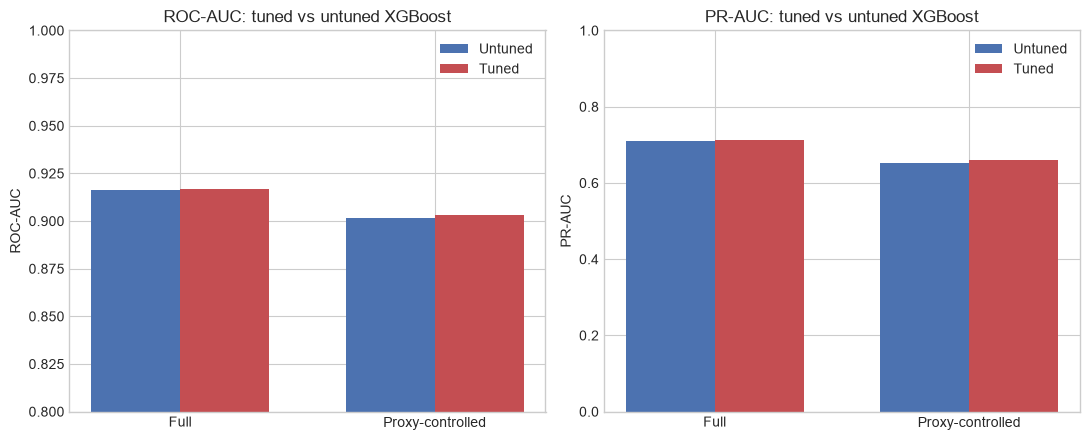

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["Full", "Proxy-controlled"]
x = np.arange(len(labels))
width = 0.35

untuned_roc = [tree_metrics["xgboost_full"]["roc_auc"], tree_metrics["xgboost_proxy_controlled"]["roc_auc"]]
tuned_roc = [metrics_tuned_full["roc_auc"], metrics_tuned_proxy["roc_auc"]]
untuned_pr = [tree_metrics["xgboost_full"]["pr_auc"], tree_metrics["xgboost_proxy_controlled"]["pr_auc"]]
tuned_pr = [metrics_tuned_full["pr_auc"], metrics_tuned_proxy["pr_auc"]]

axes[0].bar(x - width/2, untuned_roc, width, label="Untuned", color="#4C72B0")
axes[0].bar(x + width/2, tuned_roc, width, label="Tuned", color="#C44E52")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel("ROC-AUC"); axes[0].set_ylim(0.8, 1.0)
axes[0].set_title("ROC-AUC: tuned vs untuned XGBoost")
axes[0].legend()

axes[1].bar(x - width/2, untuned_pr, width, label="Untuned", color="#4C72B0")
axes[1].bar(x + width/2, tuned_pr, width, label="Tuned", color="#C44E52")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel("PR-AUC"); axes[1].set_ylim(0, 1.0)
axes[1].set_title("PR-AUC: tuned vs untuned XGBoost")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Save tuned models + search results

In [10]:
MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(tuned_xgb_full, MODELS_DIR / "xgboost_tuned_full.joblib")
joblib.dump(tuned_xgb_proxy, MODELS_DIR / "xgboost_tuned_proxy_controlled.joblib")

with open(MODELS_DIR / "xgboost_tuning_results.json", "w") as f:
    json.dump({
        "full_feature_set": {
            "best_params": best_params_full,
            "best_validation_roc_auc": best_val_auc_full,
            "test_metrics": metrics_tuned_full,
        },
        "proxy_controlled_set": {
            "best_params": best_params_proxy,
            "best_validation_roc_auc": best_val_auc_proxy,
            "test_metrics": metrics_tuned_proxy,
        },
        "param_distributions_searched": PARAM_DIST,
        "n_iter": N_ITER,
        "scale_pos_weight_fixed": float(scale_pos_weight),
        "selection_metric": "roc_auc",
    }, f, indent=2)

comparison.to_csv(MODELS_DIR / "model_comparison_final.csv")

print("Saved:")
for p in sorted(MODELS_DIR.glob("*")):
    print(" ", p)


Saved:
  ..\models\baseline_logreg_full.joblib
  ..\models\baseline_logreg_proxy_controlled.joblib
  ..\models\baseline_metrics.json
  ..\models\model_comparison.csv
  ..\models\model_comparison_final.csv
  ..\models\random_forest_full.joblib
  ..\models\random_forest_proxy_controlled.joblib
  ..\models\tree_model_metrics.json
  ..\models\xgboost_full.joblib
  ..\models\xgboost_proxy_controlled.joblib
  ..\models\xgboost_tuned_full.joblib
  ..\models\xgboost_tuned_proxy_controlled.joblib
  ..\models\xgboost_tuning_results.json


## 8. Findings

- **Read the delta print-out in §6 for the actual ROC-AUC/PR-AUC gain from tuning in this run** —
  the bullets below describe how to interpret it, not a fixed expected number.
- A **small gain (a few tenths of a point of ROC-AUC or less)** would indicate the untuned defaults
  (`max_depth=6`, `n_estimators=200`, `learning_rate=0.1`) from `03_tree_models.ipynb` were already
  close to a good operating point for this dataset — a common outcome for XGBoost on tabular data
  with this many rows, since more data reduces the marginal value of tuning regularization-related
  parameters like `subsample`/`colsample_bytree`.
- **Check whether the best parameters differ meaningfully between the full and proxy-controlled
  feature sets** (`xgboost_tuning_results.json`). If the proxy-controlled search favors a deeper
  tree or lower `min_child_weight`, that's consistent with the model needing more capacity to
  extract signal now that the mechanically-strong proxy features are gone.
- **This search used a single validation split and 15 random candidates per feature set** — a
  genuinely small search chosen for feasibility on a ~7.4GB-RAM host, not an exhaustive one. A
  wider/deeper search (more `n_iter`, proper k-fold CV, early stopping on validation logloss) is
  the natural next step if more compute becomes available.
- **No SMOTE was used**, and the source dataset file was not modified — only the two tuned
  pipelines, a tuning-results JSON, and an updated comparison CSV were written to `models/`.
